# SECTION 1: EXPLORATORY DATA ANALYSIS

## 1. Import necessary libraries and dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import statsmodels.api as sm

In [2]:
# Import dataset
df = pd.read_excel('koalas_dataset.xlsx')

## 2. Understand general information of dataset and rename the column

In [3]:
# Check the number of columns and rows
total_rows, total_columns = df.shape
print(f"Total columns of dataset: {total_columns}")
print(f"Total rows of dataset: {total_rows}")

Total columns of dataset: 14
Total rows of dataset: 104


In [4]:
df.head(1)

,koala_id,region,habitat,gender,age_in_years,Paw Size,total_length,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference
0,1,1,VIC,m,8.0,16.0,77.0,19.1,19.5,24.5,15.4,2.2,63.0,61.0


In [5]:
# Rename a single column
df.rename(columns={'Paw Size': 'paw_size'}, inplace=True)

In [6]:
# Dropping columns 'koala_id' and 'region' and then getting descriptive statistics
df.drop(columns=['koala_id', 'region']).describe().loc[['count', 'mean', '50%']]

,age_in_years,paw_size,total_length,head_length,ear_size,foot_length,skull_width,eye_diameter,chest_circumference,belly_circumference
count,102.000000,104.000000,104.000000,104.000000,104.00,102.000000,103.000000,104.000000,104.0,103.000000
mean,3.833333,17.009615,75.088462,18.554808,22.65,18.461765,12.917476,5.886538,62.0,57.582524
50%,3.000000,17.000000,76.000000,17.850000,11.90,17.950000,11.300000,1.900000,62.0,57.500000


## 3. Handle missing and misspelled values

### 3.1. Handle missing values

In [7]:
# Find total null values in each column
missing_values_per_column = df.isnull().sum()
print("Missing values per column:\n", missing_values_per_column)

Missing values per column:
 koala_id               0
region                 0
habitat                0
gender                 0
age_in_years           2
paw_size               0
total_length           0
head_length            0
ear_size               0
foot_length            2
skull_width            1
eye_diameter           0
chest_circumference    0
belly_circumference    1
dtype: int64


In [8]:
# Filter the DataFrame to only include rows with at least one missing value.
# Assign the filtered results to a variable named "df_rows_missing" and display the contents of the variable.
df_rows_missing = df[df.isna().any(axis=1)] 
df_rows_missing[['koala_id','age_in_years', 'foot_length', 'skull_width', 'belly_circumference']]

,koala_id,age_in_years,foot_length,skull_width,belly_circumference
40,41,5.0,NaN,12.0,55.5
43,44,NaN,20.3,6.5,52.0
45,46,NaN,22.8,9.4,60.0
64,65,5.0,NaN,12.4,63.5
75,76,5.0,14.5,11.8,NaN
88,89,6.0,14.4,NaN,55.5


In [9]:
# Fill missing values with the median of the column
df['age_in_years'] = df['age_in_years'].fillna(df['age_in_years'].median())
df['foot_length'] = df['foot_length'].fillna(df['foot_length'].median())
df['skull_width'] = df['skull_width'].fillna(df['skull_width'].median())
df['belly_circumference'] = df['belly_circumference'].fillna(df['belly_circumference'].median())

In [10]:
# Check null values in each columns
print("Missing values per column:\n",df.isnull().sum())

Missing values per column:
 koala_id               0
region                 0
habitat                0
gender                 0
age_in_years           0
paw_size               0
total_length           0
head_length            0
ear_size               0
foot_length            0
skull_width            0
eye_diameter           0
chest_circumference    0
belly_circumference    0
dtype: int64


In [11]:
# Filter and display rows with specified koala IDs to check values after replacing nulls with the mean
specific_ids = [41, 44, 46, 65, 76, 89]
filtered_rows = df[df['koala_id'].isin(specific_ids)]

# Display the selected rows with relevant columns
filtered_rows[['koala_id', 'age_in_years', 'foot_length', 'skull_width', 'belly_circumference']]

,koala_id,age_in_years,foot_length,skull_width,belly_circumference
40,41,5.0,17.95,12.0,55.5
43,44,3.0,20.30,6.5,52.0
45,46,3.0,22.80,9.4,60.0
64,65,5.0,17.95,12.4,63.5
75,76,5.0,14.50,11.8,57.5
88,89,6.0,14.40,11.3,55.5


### 3.2. Handle misspelled values

In [12]:
# Check misspelled values in each column by using unique()
# Use unique() to find unique entries in 'habitat' column
print('Unique values in habitat column: ',df['habitat'].unique().tolist())

# Correct misspelled values
corrections = {'VICtoria': 'VIC', 'Vic': 'VIC', 'Queensland': 'QLD', 'Queenstown': 'QLD', 'qld': 'QLD', 'q': 'QLD'}

# Use replace to replace the previous values with correct values
df['habitat'] = df['habitat'].replace(corrections)

# Check if the gender are correct
print('Unique values in habitat column after handling misspelled values: ',df['habitat'].unique().tolist())

Unique values in habitat column:  ['VIC', 'VICtoria', 'Vic', 'QLD', 'Queensland', 'Queenstown', 'qld', 'q']
Unique values in habitat column after handling misspelled values:  ['VIC', 'QLD']


In [13]:
# Check misspelled values in each column by using unique()
# Use unique() to find unique entries in 'gender' column
print('Unique values in gender column: ',df['gender'].unique().tolist())

# Correct misspelled values
corrections = {'male': 'm', 'female': 'f'}

# Use replace to replace the previous values with correct values
df['gender'] = df['gender'].replace(corrections)

# Check if the gender are correct
print('Unique values in gender column after handling misspelled values: ',df['gender'].unique().tolist())

Unique values in gender column:  ['m', 'f', 'female', 'male']
Unique values in gender column after handling misspelled values:  ['m', 'f']


## 4. Handle duplicates

In [14]:
#count the number of duplicates in dataset
num_duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {num_duplicates}')

Number of duplicate rows: 0


## 5. Draw histogram

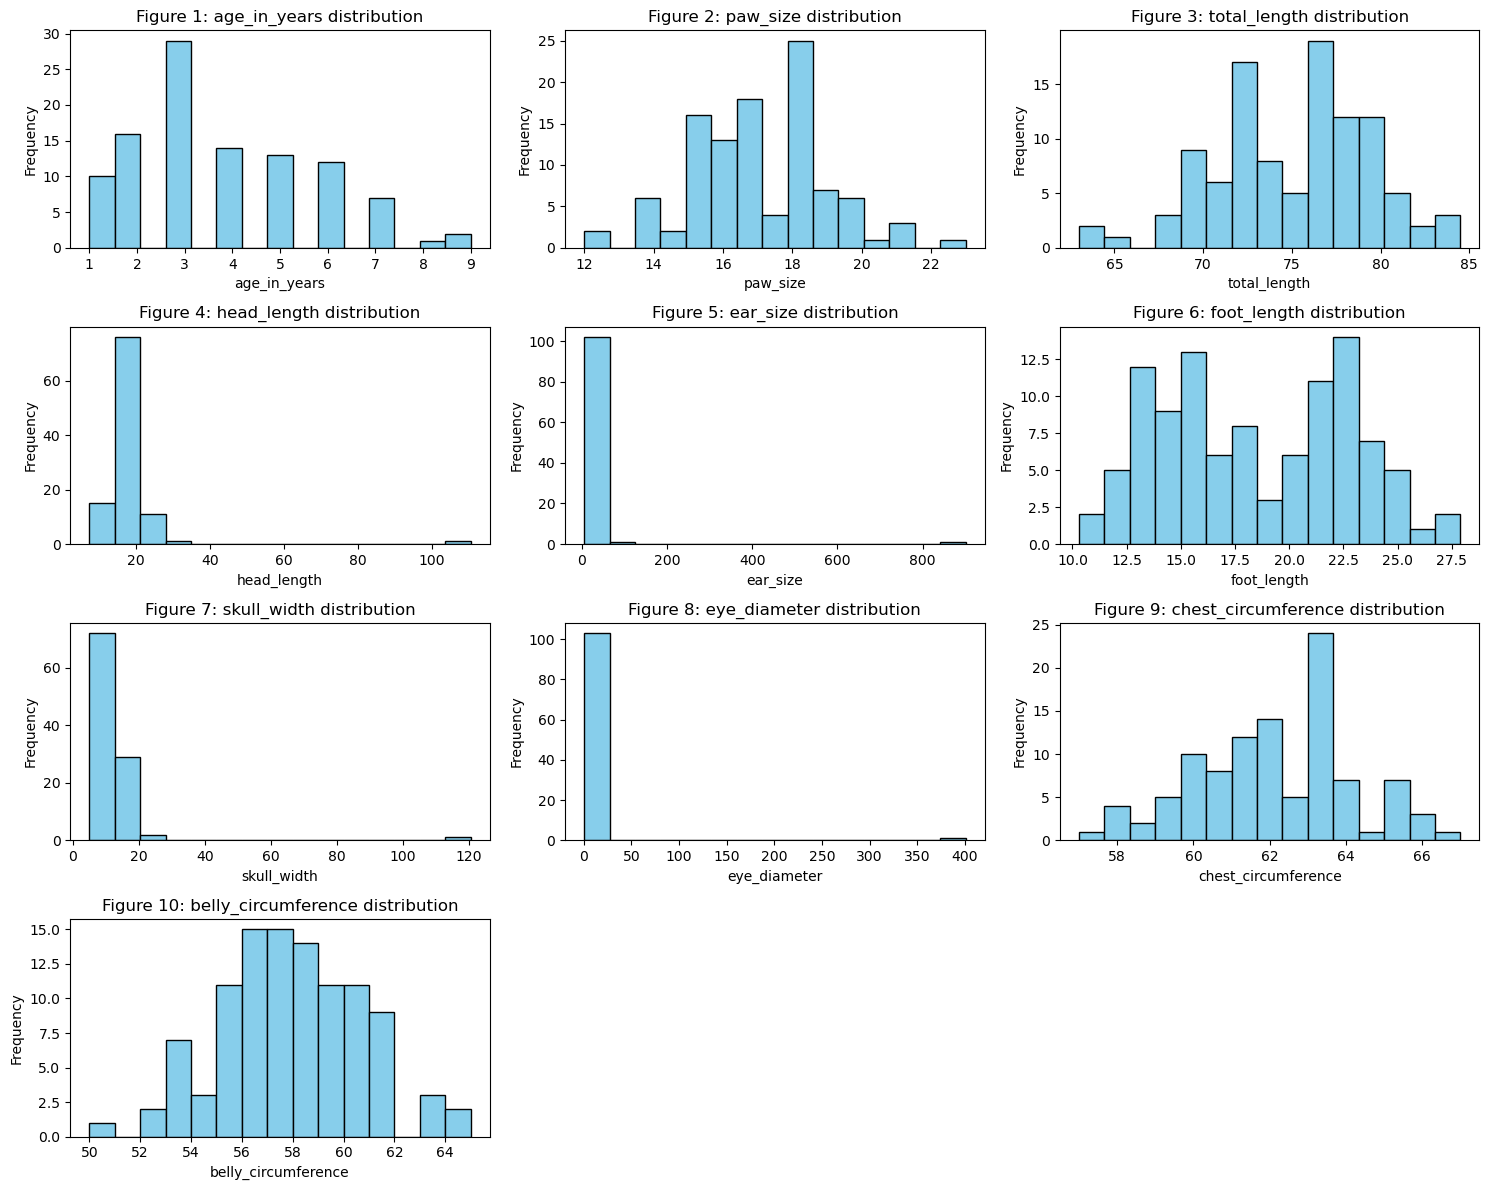

In [15]:
# Select only the numeric columns
numeric_columns = df[['age_in_years', 'paw_size', 'total_length', 'head_length', 'ear_size',
                      'foot_length', 'skull_width', 'eye_diameter', 'chest_circumference',
                      'belly_circumference']]

# Create histograms for all numeric columns
plt.figure(figsize=(15, 12)) 

# Loop through each numeric column and create a histogram
for i, col in enumerate(numeric_columns.columns, 1):
    plt.subplot(len(numeric_columns.columns) // 3 + 1, 3, i)
    plt.hist(numeric_columns[col], bins=15, color='skyblue', edgecolor='black')
    plt.title(f'Figure {i}: {col} distribution', fontsize=12)  # Adjusted title format
    plt.xlabel(col)
    plt.ylabel('Frequency')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


## 6. Outliers

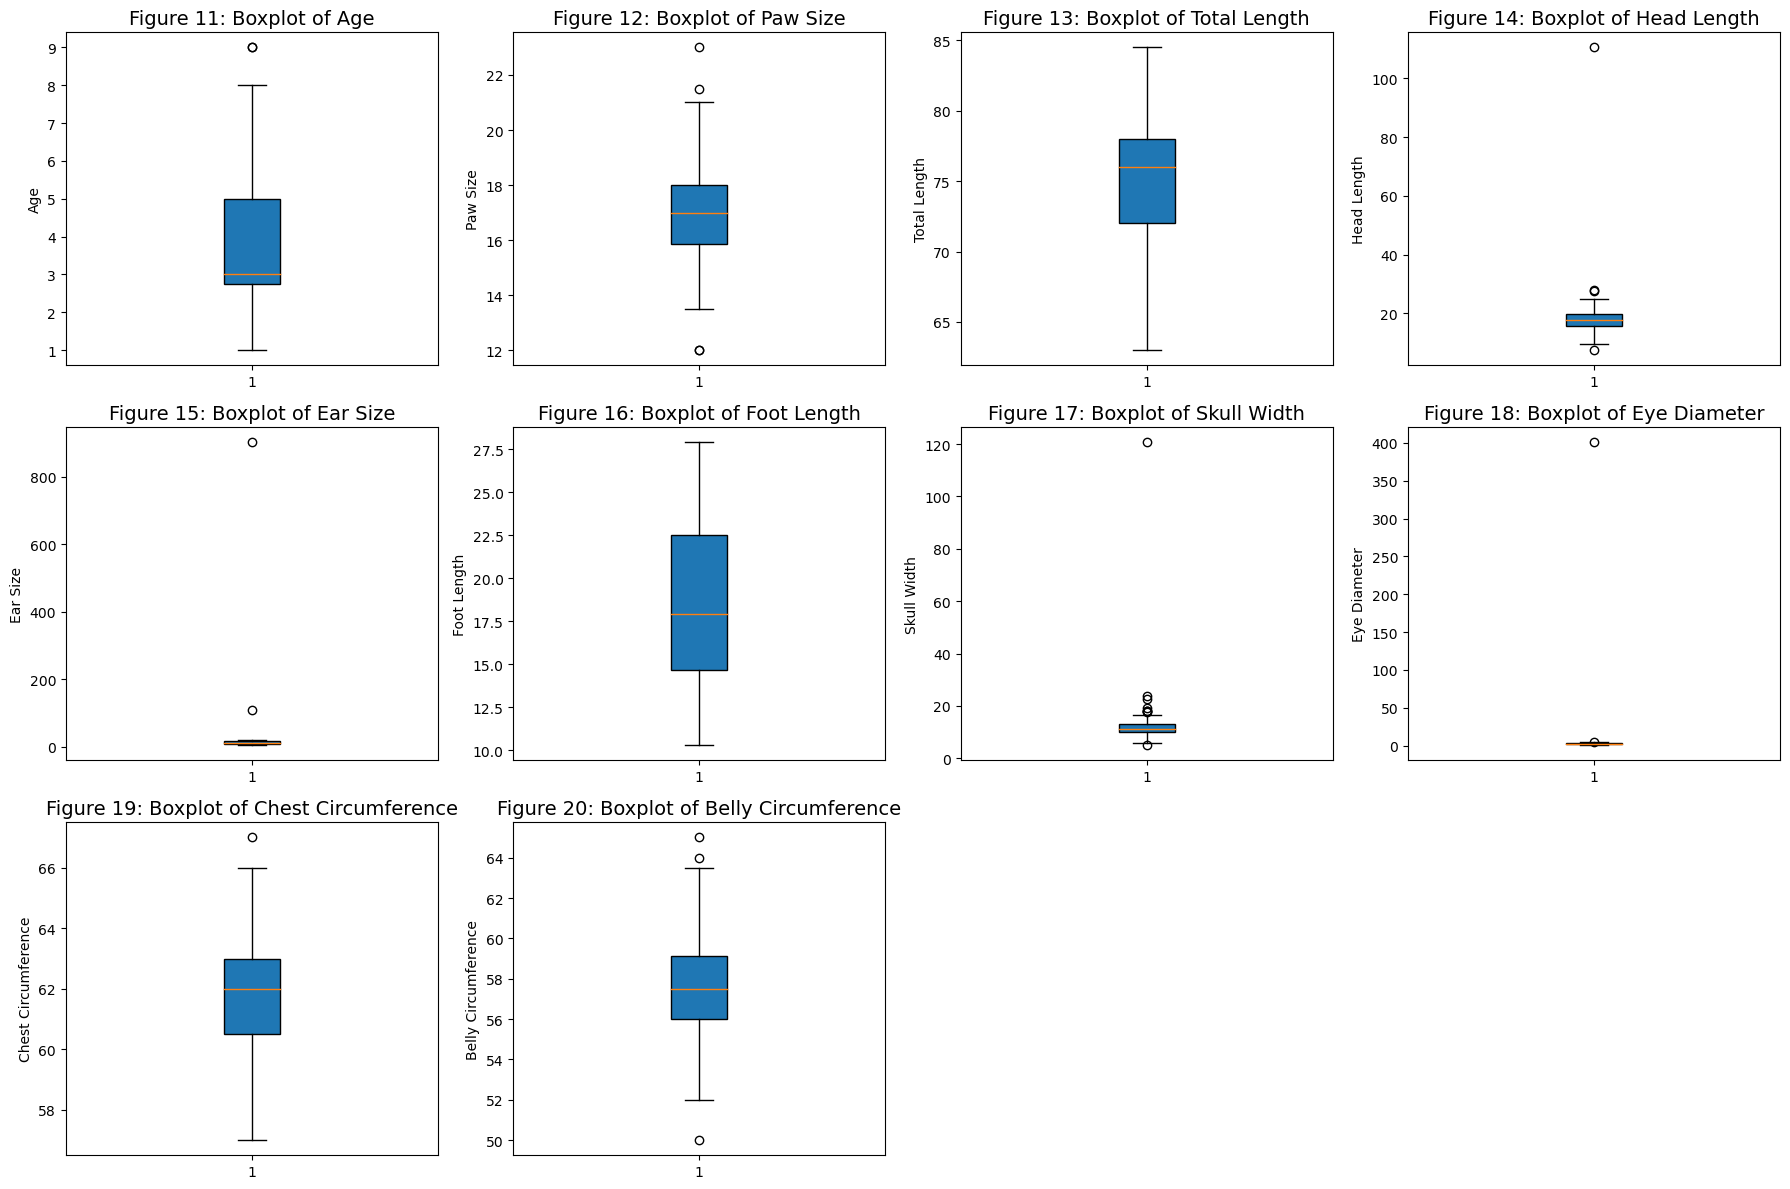

In [16]:
# Create boxplots to identify outliers
plt.figure(figsize=(18, 12))

# Age boxplot
plt.subplot(3, 4, 1)
plt.boxplot(df['age_in_years'], patch_artist=True)
plt.title('Figure 11: Boxplot of Age', fontsize=14)
plt.ylabel('Age')

# Paw Size boxplot
plt.subplot(3, 4, 2)
plt.boxplot(df['paw_size'], patch_artist=True)
plt.title('Figure 12: Boxplot of Paw Size', fontsize=14)
plt.ylabel('Paw Size')

# Total Length boxplot
plt.subplot(3, 4, 3)
plt.boxplot(df['total_length'], patch_artist=True)
plt.title('Figure 13: Boxplot of Total Length', fontsize=14)
plt.ylabel('Total Length')

# Head Length boxplot
plt.subplot(3, 4, 4)
plt.boxplot(df['head_length'], patch_artist=True)
plt.title('Figure 14: Boxplot of Head Length', fontsize=14)
plt.ylabel('Head Length')

# Ear Size boxplot
plt.subplot(3, 4, 5)
plt.boxplot(df['ear_size'], patch_artist=True)
plt.title('Figure 15: Boxplot of Ear Size', fontsize=14)
plt.ylabel('Ear Size')

# Foot Length boxplot
plt.subplot(3, 4, 6)
plt.boxplot(df['foot_length'], patch_artist=True)
plt.title('Figure 16: Boxplot of Foot Length', fontsize=14)
plt.ylabel('Foot Length')

# Skull Width boxplot
plt.subplot(3, 4, 7)
plt.boxplot(df['skull_width'], patch_artist=True)
plt.title('Figure 17: Boxplot of Skull Width', fontsize=14)
plt.ylabel('Skull Width')

# Eye Diameter boxplot
plt.subplot(3, 4, 8)
plt.boxplot(df['eye_diameter'], patch_artist=True)
plt.title('Figure 18: Boxplot of Eye Diameter', fontsize=14)
plt.ylabel('Eye Diameter')

# Chest Circumference boxplot
plt.subplot(3, 4, 9)
plt.boxplot(df['chest_circumference'], patch_artist=True)
plt.title('Figure 19: Boxplot of Chest Circumference', fontsize=14)
plt.ylabel('Chest Circumference')

# Belly Circumference boxplot
plt.subplot(3, 4, 10)
plt.boxplot(df['belly_circumference'], patch_artist=True)
plt.title('Figure 20: Boxplot of Belly Circumference', fontsize=14)
plt.ylabel('Belly Circumference')

plt.tight_layout()
plt.show()

**Columns has outliers:** 
- age_in_years
- paw_size
- head_length
- ear_size
- skull_width
- eye_diameter
- chest_circumference
- belly_circumference

### 6.1. age_in_years

In [17]:
# Find first and third percentile of age column
# Caluclate 25th percentile of age column
percentile25 = df['age_in_years'].quantile(0.25)

# Caluclate 75th percentile of age column
percentile75 = df['age_in_years'].quantile(0.75)

# Calculate interquartile range
iqr = percentile75 - percentile25

# Calcualte upper and lower thresholds for outliers
upper_limit = percentile75 + 1.5 *iqr
lower_limit = percentile25 - 1.5 * iqr
print('Upper limit of age_in_years column:' + str(upper_limit))
print('Lower limit of age_in_years column:' + str(lower_limit))

# Filter the DataFrame to only include rows having outlier in age column
# Assign the filtered results to a variable named "outlier_age_in_years"
outlier_age_in_years = df[(df['age_in_years'] < lower_limit) | (df['age_in_years'] > upper_limit)]

# # Display the 'koala_id' and 'age_in_years' for the identified outliers
outlier_age_in_years[['koala_id','age_in_years']]

Upper limit of age_in_years column:8.375
Lower limit of age_in_years column:-0.625


,koala_id,age_in_years
8,9,9.0
10,11,9.0


In [18]:
# Calculate the medians
paw_size_median = df['paw_size'].median()
head_length_median = df['head_length'].median()
ear_size_median = df['ear_size'].median()
skull_width_median = df['skull_width'].median()
eye_diameter_median = df['eye_diameter'].median()
chest_circumference_median = df['chest_circumference'].median()
belly_circumference_median = df['belly_circumference'].median()

# Print all the medians
print('Median value of paw_size column:', paw_size_median)
print('Median value of head_length column:', head_length_median)
print('Median value of ear_size column:', ear_size_median)
print('Median value of skull_width column:', skull_width_median)
print('Median value of eye_diameter column:', eye_diameter_median)
print('Median value of chest_circumference column:', chest_circumference_median)
print('Median value of belly_circumference column:', belly_circumference_median)

Median value of paw_size column: 17.0
Median value of head_length column: 17.85
Median value of ear_size column: 11.9
Median value of skull_width column: 11.3
Median value of eye_diameter column: 1.9
Median value of chest_circumference column: 62.0
Median value of belly_circumference column: 57.5


### 6.2. paw_size

In [19]:
# Find first and third percentile of paw_size column
# Caluclate 25th percentile of paw_size column
percentile25 = df['paw_size'].quantile(0.25)

# Caluclate 75th percentile of paw_size column
percentile75 = df['paw_size'].quantile(0.75)

# Calculate interquartile range
iqr = percentile75 - percentile25

# Calcualte upper and lower thresholds for outliers
upper_limit = percentile75 + 1.5 *iqr
lower_limit = percentile25 - 1.5 * iqr
print('Upper limit of paw_size column:' + str(upper_limit))
print('Lower limit of paw_size column:' + str(lower_limit))

# Filter the DataFrame to only include rows having outlier in paw_size column
# Assign the filtered results to a variable named "outlier_paw_size"
outlier_paw_size = df[(df['paw_size'] < lower_limit) | (df['paw_size'] > upper_limit)]

# Display the 'koala_id' and 'paw_size' for the identified outliers
outlier_paw_size[['koala_id','paw_size']]

Upper limit of paw_size column:21.1875
Lower limit of paw_size column:12.6875


,koala_id,paw_size
41,42,12.0
42,43,12.0
53,54,23.0
86,87,21.5


In [20]:
# Replace outlier values in 'paw_size' with the median value
df.loc[(df['paw_size'] < lower_limit) | (df['paw_size'] > upper_limit), 'paw_size'] = paw_size_median

# Filter the DataFrame to include only the specified koala IDs
specific_ids = [42, 43, 54, 87]
filtered_rows = df[df['koala_id'].isin(specific_ids)]

# Display the 'koala_id' and 'paw_size' for the selected rows
filtered_rows[['koala_id', 'paw_size']]

,koala_id,paw_size
41,42,17.0
42,43,17.0
53,54,17.0
86,87,17.0


### 6.3. head_length

In [21]:
# Find first and third percentile of head_length column
# Caluclate 25th percentile of head_length column
percentile25 = df['head_length'].quantile(0.25)

# Caluclate 75th percentile of price column
percentile75 = df['head_length'].quantile(0.75)

# Calculate interquartile range
iqr = percentile75 - percentile25

# Calcualte upper and lower thresholds for outliers
upper_limit = percentile75 + 1.5 *iqr
lower_limit = percentile25 - 1.5 * iqr
print('Upper limit of head_length column:' + str(upper_limit))
print('Lower limit of head_length column:' + str(lower_limit))

# Filter the DataFrame to only include rows having outlier in head_length column
# Assign the filtered results to a variable named "outlier_head_length"
outlier_head_length = df[(df['head_length'] < lower_limit) | (df['head_length'] > upper_limit)]

# Display the 'koala_id' and 'head_length' for the identified outliers
outlier_head_length[['koala_id','head_length']]

Upper limit of head_length column:25.950000000000003
Lower limit of head_length column:9.549999999999997


,koala_id,head_length
54,55,28.1
58,59,27.5
72,73,7.5
77,78,110.5


In [22]:
# Replace outlier values in 'head_length' with the median value
df.loc[(df['head_length'] < lower_limit) | (df['head_length'] > upper_limit), 'head_length'] = head_length_median

# Filter the DataFrame to include only the specified koala IDs
specific_ids = [55, 59, 73, 78]
filtered_rows = df[df['koala_id'].isin(specific_ids)]

# Display the 'koala_id' and 'head_length' for the selected rows
filtered_rows[['koala_id', 'head_length']]

,koala_id,head_length
54,55,17.85
58,59,17.85
72,73,17.85
77,78,17.85


### 6.4. ear_size

In [23]:
# Find first and third percentile of ear_size column
# Caluclate 25th percentile of ear_size column
percentile25 = df['ear_size'].quantile(0.25)

# Caluclate 75th percentile of ear_size column
percentile75 = df['ear_size'].quantile(0.75)

# Calculate interquartile range
iqr = percentile75 - percentile25

# Calcualte upper and lower thresholds for outliers
upper_limit = percentile75 + 1.5 *iqr
lower_limit = percentile25 - 1.5 * iqr
print('Upper limit of ear_size column:' + str(upper_limit))
print('Lower limit of ear_size column:' + str(lower_limit))

# Filter the DataFrame to only include rows having outlier in ear_size column
# Assign the filtered results to a variable named "outlier_ear_size"
outlier_ear_size = df[(df['ear_size'] < lower_limit) | (df['ear_size'] > upper_limit)]

# Display the 'koala_id' and 'ear_size' for the identified outliers
outlier_ear_size[['koala_id','ear_size']]

Upper limit of ear_size column:27.749999999999996
Lower limit of ear_size column:-0.8499999999999979


,koala_id,ear_size
57,58,110.4
89,90,900.8


In [24]:
# Replace outlier values in 'ear_size' with the median value
df.loc[(df['ear_size'] < lower_limit) | (df['ear_size'] > upper_limit), 'ear_size'] = ear_size_median

# Filter the DataFrame to include only the specified koala IDs
specific_ids = [58, 90]
filtered_rows = df[df['koala_id'].isin(specific_ids)]

# Display the 'koala_id' and 'ear_size' for the selected rows
filtered_rows[['koala_id', 'ear_size']]

,koala_id,ear_size
57,58,11.9
89,90,11.9


### 6.5. skull_width

In [25]:
# Find first and third percentile of skull_width column
# Caluclate 25th percentile of skull_width column
percentile25 = df['skull_width'].quantile(0.25)

# Caluclate 75th percentile of skull_width column
percentile75 = df['skull_width'].quantile(0.75)

# Calculate interquartile range
iqr = percentile75 - percentile25

# Calcualte upper and lower thresholds for outliers
upper_limit = percentile75 + 1.5 *iqr
lower_limit = percentile25 - 1.5 * iqr
print('Upper limit of skull_width column:' + str(upper_limit))
print('Lower limit of skull_width column:' + str(lower_limit))

# Filter the DataFrame to only include rows having outlier in skull_width column
# Assign the filtered results to a variable named "outlier_skull_width"
outlier_skull_width = df[(df['skull_width'] < lower_limit) | (df['skull_width'] > upper_limit)]

# Display the 'koala_id' and 'skull_width' for the identified outliers
outlier_skull_width[['koala_id','skull_width']]

Upper limit of skull_width column:17.7875
Lower limit of skull_width column:5.2875


,koala_id,skull_width
14,15,120.6
16,17,22.7
47,48,18.2
53,54,18.0
54,55,18.2
57,58,19.2
58,59,17.8
78,79,5.0
97,98,23.6


In [26]:
# Replace outlier values in 'skull_width' with the median value
df.loc[(df['skull_width'] < lower_limit) | (df['skull_width'] > upper_limit), 'skull_width'] = skull_width_median

# Filter the DataFrame to include only the specified koala IDs
specific_ids = [15, 17, 48, 54, 55, 58, 59, 79, 98]
filtered_rows = df[df['koala_id'].isin(specific_ids)]

# Display the 'koala_id' and 'skull_width' for the selected rows
filtered_rows[['koala_id', 'skull_width']]

,koala_id,skull_width
14,15,11.3
16,17,11.3
47,48,11.3
53,54,11.3
54,55,11.3
57,58,11.3
58,59,11.3
78,79,11.3
97,98,11.3


### 6.6. eye_diameter

In [27]:
# Find first and third percentile of Eye Diameter column
# Caluclate 25th percentile of Eye Diameter column
percentile25 = df['eye_diameter'].quantile(0.25)

# Caluclate 75th percentile of Eye Diameter column
percentile75 = df['eye_diameter'].quantile(0.75)

# Calculate interquartile range
iqr = percentile75 - percentile25

# Calcualte upper and lower thresholds for outliers
upper_limit = percentile75 + 1.5 *iqr
lower_limit = percentile25 - 1.5 * iqr
print('Upper limit of eye_diameter column:' + str(upper_limit))
print('Lower limit of eye_diameter column:' + str(lower_limit))

# Filter the DataFrame to only include rows having outlier in eye_diameter column
# Assign the filtered results to a variable named "outlier_eye_diameter"
outlier_eye_diameter = df[(df['eye_diameter'] < lower_limit) | (df['eye_diameter'] > upper_limit)]

# Display the 'koala_id' and 'eye_diameter' for the identified outliers
outlier_eye_diameter[['koala_id','eye_diameter']]

Upper limit of eye_diameter column:4.7125
Lower limit of eye_diameter column:-0.5875000000000004


,koala_id,eye_diameter
53,54,400.5
75,76,4.8


In [28]:
# Replace outlier values in 'eye_diameter' with the median value
df.loc[(df['eye_diameter'] < lower_limit) | (df['eye_diameter'] > upper_limit), 'eye_diameter'] = eye_diameter_median

# Filter the DataFrame to include only the specified koala IDs
specific_ids = [54, 76]
filtered_rows = df[df['koala_id'].isin(specific_ids)]

# Display the 'koala_id' and 'eye_diameter' for the selected rows
filtered_rows[['koala_id', 'eye_diameter']]

,koala_id,eye_diameter
53,54,1.9
75,76,1.9


### 6.7. chest_circumference

In [29]:
# Find first and third percentile of chest_circumference column
# Caluclate 25th percentile of chest_circumference column
percentile25 = df['chest_circumference'].quantile(0.25)

# Caluclate 75th percentile of chest_circumference column
percentile75 = df['chest_circumference'].quantile(0.75)

# Calculate interquartile range
iqr = percentile75 - percentile25

# Calcualte upper and lower thresholds for outliers
upper_limit = percentile75 + 1.5 *iqr
lower_limit = percentile25 - 1.5 * iqr
print('Upper limit of chest_circumference column:' + str(upper_limit))
print('Lower limit of chest_circumference column:' + str(lower_limit))

# Filter the DataFrame to only include rows having outlier in chest_circumference column
# Assign the filtered results to a variable named "outlier_chest_circumference"
outlier_chest_circumference = df[(df['chest_circumference'] < lower_limit) | (df['chest_circumference'] > upper_limit)]

# Display the 'koala_id' and 'chest_circumference' for the identified outliers
outlier_chest_circumference[['koala_id','chest_circumference']]

Upper limit of chest_circumference column:66.75
Lower limit of chest_circumference column:56.75


,koala_id,chest_circumference
58,59,67.0


In [30]:
# Replace outlier values in 'chest_circumference' with the median value
df.loc[(df['chest_circumference'] < lower_limit) | (df['chest_circumference'] > upper_limit), 'chest_circumference'] = chest_circumference_median

# Filter the DataFrame to include only the row with the specified koala ID
specific_row = df[df['koala_id'] == 59]

# Display the 'koala_id' and 'chest_circumference' for the selected row
specific_row[['koala_id', 'chest_circumference']]

,koala_id,chest_circumference
58,59,62.0


### 6.8. belly_circumference

In [31]:
# Find first and third percentile of belly_circumference column
# Calculate 25th percentile of belly_circumference column
percentile25_belly = df['belly_circumference'].quantile(0.25)

# Calculate 75th percentile of belly_circumference column
percentile75_belly = df['belly_circumference'].quantile(0.75)

# Calculate interquartile range
iqr_belly = percentile75_belly - percentile25_belly

# Calculate upper and lower thresholds for outliers
upper_limit_belly = percentile75_belly + 1.5 * iqr_belly
lower_limit_belly = percentile25_belly - 1.5 * iqr_belly

# Print the upper and lower limits for belly_circumference
print('Upper limit of belly_circumference column: ' + str(upper_limit_belly))
print('Lower limit of belly_circumference column: ' + str(lower_limit_belly))

# Filter the DataFrame to only include rows having outliers in belly_circumference column
# Assign the filtered results to a variable named "outlier_belly_circumference"
outlier_belly_circumference = df[(df['belly_circumference'] < lower_limit_belly) | (df['belly_circumference'] > upper_limit_belly)]

# Display the 'koala_id' and 'belly_circumference' for the identified outliers
outlier_belly_circumference[['koala_id','belly_circumference']]

Upper limit of belly_circumference column: 63.8125
Lower limit of belly_circumference column: 51.3125


,koala_id,belly_circumference
20,21,65.0
38,39,50.0
56,57,64.0


In [32]:
# Replace outlier values in 'belly_circumference' with the median value
df.loc[(df['belly_circumference'] < lower_limit_belly) | (df['belly_circumference'] > upper_limit_belly), 'belly_circumference'] = belly_circumference_median

# Filter the DataFrame to include only the rows with specified koala IDs
specific_row = df[df['koala_id'].isin([21, 39, 57])]

# Display the 'koala_id' and 'belly_circumference' for the selected rows
specific_row[['koala_id', 'belly_circumference']]

,koala_id,belly_circumference
20,21,57.5
38,39,57.5
56,57,57.5


# SECTION 2: DATA VISUALIZATION

## 1. Physical characteristics by habitat

C:\Users\Nguyen Thu Uyen\AppData\Local\Temp\ipykernel_28356\241298123.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='habitat', y=characteristic, data=df, palette='Set1')  # Set color palette to 'Set1'
C:\Users\Nguyen Thu Uyen\AppData\Local\Temp\ipykernel_28356\241298123.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='habitat', y=characteristic, data=df, palette='Set1')  # Set color palette to 'Set1'
C:\Users\Nguyen Thu Uyen\AppData\Local\Temp\ipykernel_28356\241298123.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='h

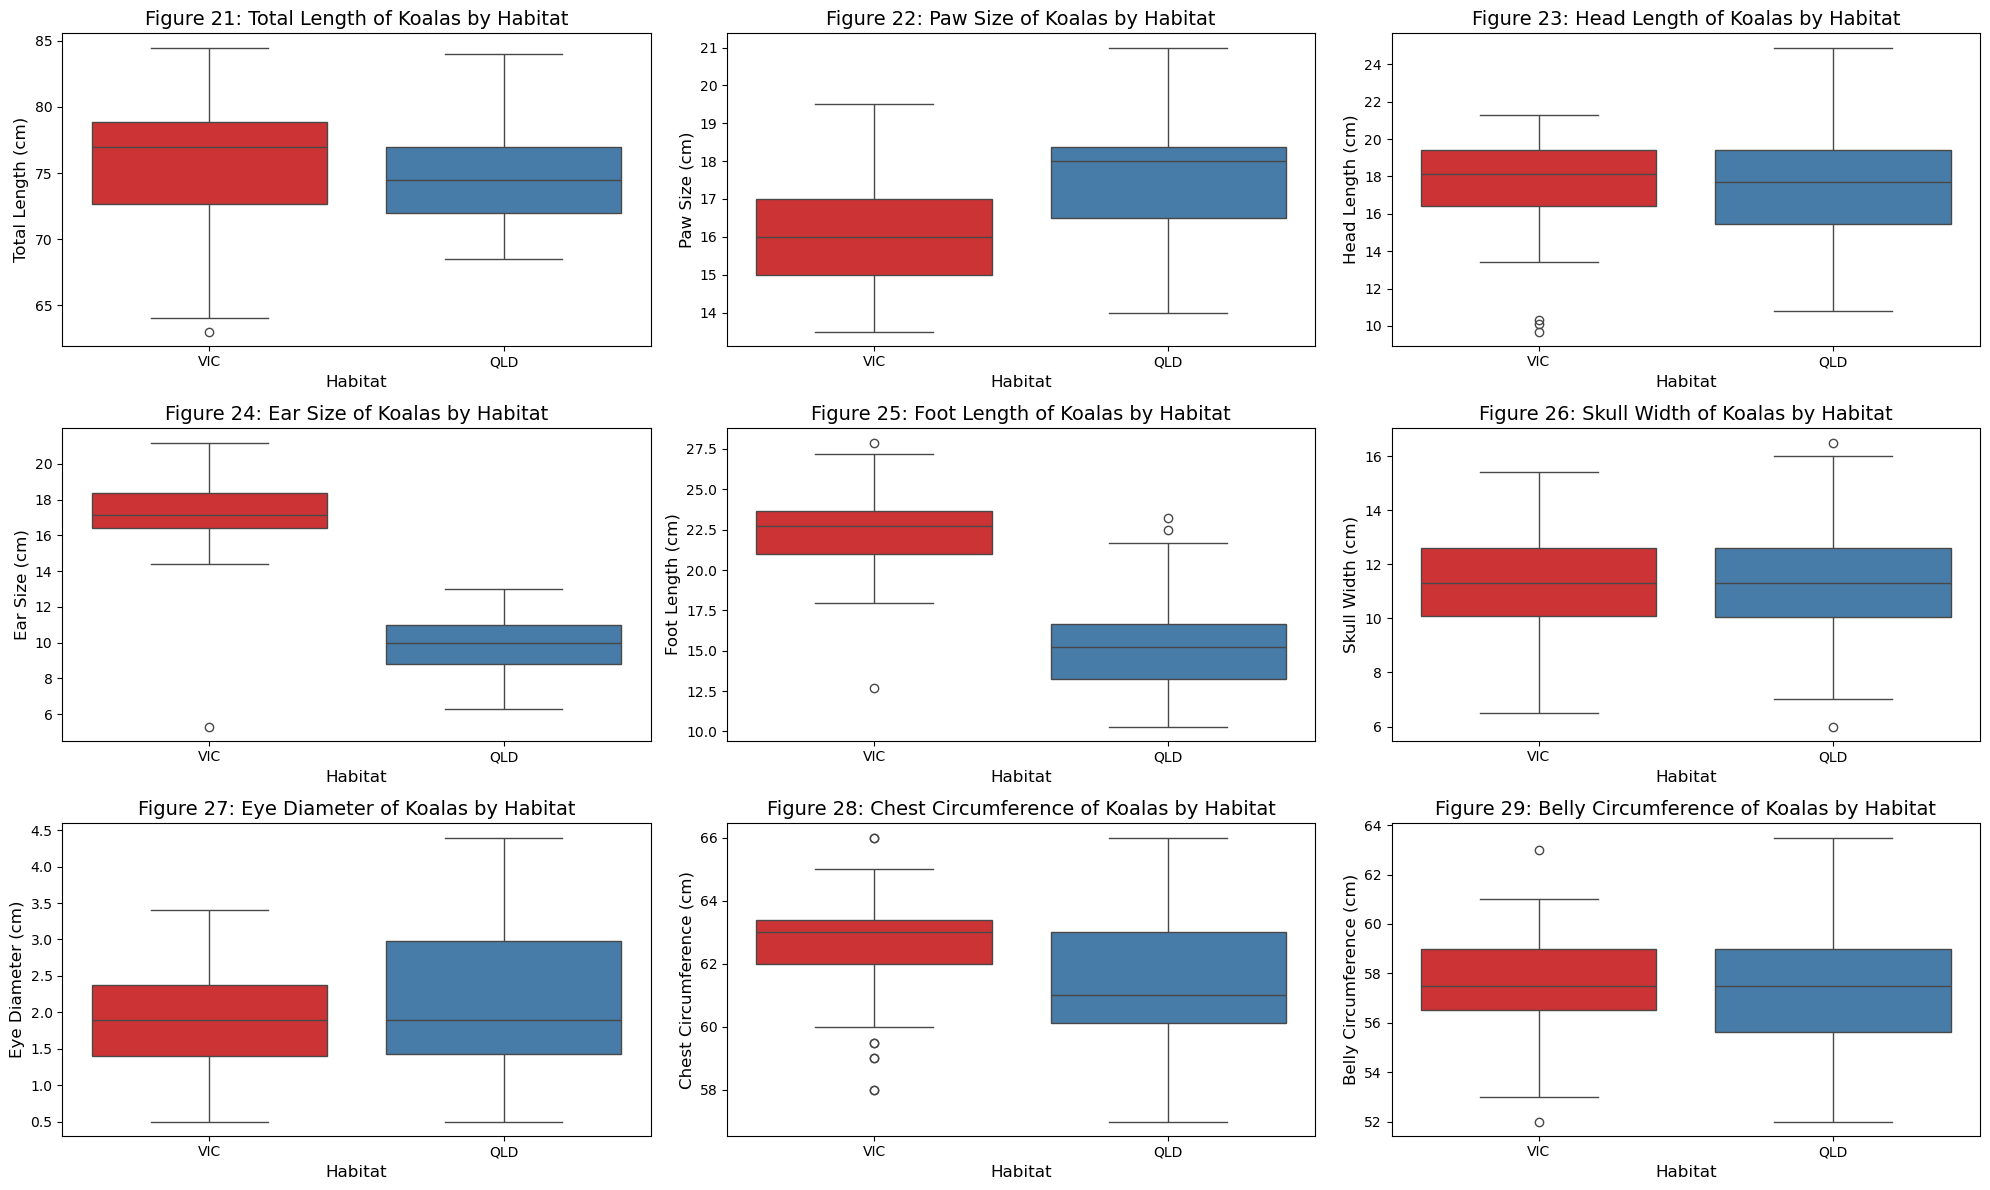

In [33]:
# Define the list of physical characteristics to plot
physical_characteristics = ['total_length', 'paw_size', 'head_length', 'ear_size', 'foot_length', 'skull_width', 'eye_diameter', 'chest_circumference', 'belly_circumference']

# Set the size of the overall figure
plt.figure(figsize=(20, 12))

# Loop through each characteristic and create a boxplot with figure numbers starting from 20
for i, characteristic in enumerate(physical_characteristics, 1):
    plt.subplot(3, 3, i)  # Create a grid of 3 rows, 3 columns for the plots
    sns.boxplot(x='habitat', y=characteristic, data=df, palette='Set1')  # Set color palette to 'Set1'
    plt.title(f'Figure {20 + i}: {characteristic.replace("_", " ").title()} of Koalas by Habitat', fontsize=14)
    plt.xlabel('Habitat', fontsize=12)
    plt.ylabel(f'{characteristic.replace("_", " ").title()} (cm)', fontsize=12)

# Adjust the layout to avoid overlap
plt.tight_layout()
plt.show()


## 2. Gender distribution by habitat

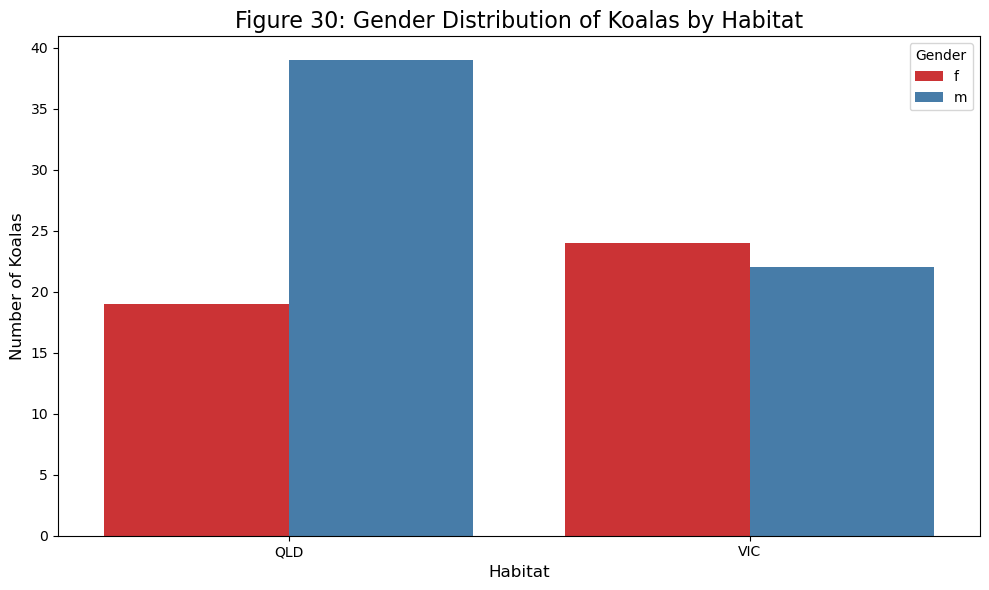

In [34]:
# Create a new DataFrame to count gender by habitat
gender_counts = df.groupby(['habitat', 'gender']).size().reset_index(name='count')

# Create a figure for the bar chart
plt.figure(figsize=(10, 6))

# Create a bar plot
sns.barplot(data=gender_counts, x='habitat', y='count', hue='gender', palette='Set1')

# Add titles and labels, including the figure number
plt.title('Figure 30: Gender Distribution of Koalas by Habitat', fontsize=16)
plt.xlabel('Habitat', fontsize=12)
plt.ylabel('Number of Koalas', fontsize=12)
plt.legend(title='Gender')

# Show the plot
plt.tight_layout()
plt.show()

# SECTION 3: ANALYSIS

## Question 1: Is the mean head length of the Koalas significantly different from 92.0 mm (0.92 cm)?

In [35]:
# Step 1: State the Null Hypothesis and the Alternative Hypothesis

Null Hypothesis (H0): The mean head length of the Koalas is 0.92 cm. (μ = 0.92)

Alternative Hypothesis (Ha): The mean head length of the Koalas is different from 0.92 cm. (μ ≠ 0.92)

In [36]:
# Step 2: Choose a Significance Level

We'll use a significance level of 0.05 (5%).

In [37]:
# Step 3: Perform the One-Sample z-test and Find the p-value

In [38]:
# Assuming 'df' is your DataFrame with the 'head_length' column
head_length = df['head_length']

# Hypothesized population mean
population_mean = 0.92

# Perform one-sample z-test
z_statistic, p_value = sm.stats.ztest(head_length, value=population_mean)

# Print z-statistic and p-value with full precision
print(f"z-statistic: {z_statistic:.3f}")  
print(f"p-value: {p_value:.3f}")          

z-statistic: 55.398
p-value: 0.000


In [39]:
# Step 4: Draw conclusion

In [40]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis. The mean head length of the Koalas is different from 0.92 cm.")
else:
    print("Fail to reject the null hypothesis. The data does not provide sufficient evidence that The mean head length of the Koalas.")

Reject the null hypothesis. The mean head length of the Koalas is different from 0.92 cm.


## Question 2: Do male and female Koalas have significantly different mean head lengths?

In [41]:
# Step 1: State the Null Hypothesis and the Alternative Hypothesis

Null Hypothesis (H0):There is no difference between the mean head lengths of male and female koalas. (μ male = μ female)

Alternative Hypothesis (Ha): Male and female Koalas have significantly different mean head lengths (μ male ≠ μ female)

In [42]:
# Step 2: Choose a Significance Level

We'll use a significance level of 0.05 (5%).

In [43]:
# Step 3: Perform the Two-Sample t-test and Find the p-value

In [44]:
# Split the data into two groups based on gender
male_head_lengths = df[df['gender'] == 'm']['head_length']
female_head_lengths = df[df['gender'] == 'f']['head_length']

# Perform the two-sample t-test
t_statistic, p_value = stats.ttest_ind(male_head_lengths, female_head_lengths)

print("t-statistic:", t_statistic)
print("p-value:", p_value)

t-statistic: 1.1845909185649293
p-value: 0.23893211144290333


In [45]:
# Step 4: Draw conclusion

In [46]:
alpha = 0.05

# Decide based on the p-value from the two-sample t-test
if p_value < alpha:
    print("Reject the null hypothesis. The mean head length of male and female koalas is significantly different.")
else:
    print("Fail to reject the null hypothesis. The data does not provide sufficient evidence that the mean head length of male and female koalas is different.")

Fail to reject the null hypothesis. The data does not provide sufficient evidence that the mean head length of male and female koalas is different.


## Question 3: Can we predict the total length of a Koala based on its head length?

In [47]:
# Subset Data
ols_data = df[["total_length", "head_length"]]

# Write out formula  = Y~X
ols_formula = "total_length ~ head_length"

# Import ols function
from statsmodels.formula.api import ols


# Build OLS, fit model to data
OLS = ols(formula = ols_formula, data = ols_data)
model = OLS.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           total_length   R-squared:                       0.403
Model:                            OLS   Adj. R-squared:                  0.397
Method:                 Least Squares   F-statistic:                     68.76
Date:                Mon, 14 Oct 2024   Prob (F-statistic):           4.73e-13
Time:                        22:44:17   Log-Likelihood:                -272.22
No. Observations:                 104   AIC:                             548.4
Df Residuals:                     102   BIC:                             553.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      59.4088      1.919     30.955      0.000      55.602      63.216
head_length     0.8923      0.108      8.292      0.000       0.679       1.106
==============================================================================
Omnibus:                        0.043   Durbin-Watson:                   1.580
Prob(Omnibus):                  0.979   Jarque-Bera (JB):                0.190
Skew:                           0.017   Prob(JB):                        0.909
Kurtosis:                       2.793   Cond. No.                         105.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [48]:
# Check assumption

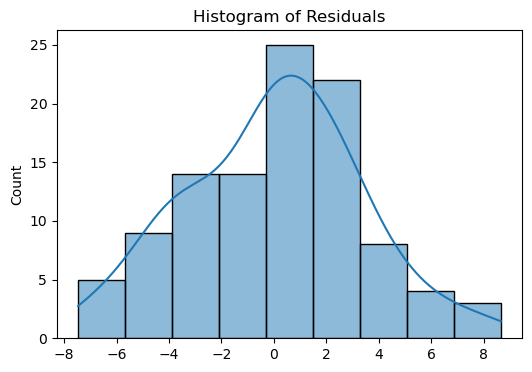

In [49]:
#lets check the Normality: The errors are normally distribute.*
# Extract residuals and fitted values
residuals = model.resid
fitted_values = model.fittedvalues

# Plot 2: Histogram of Residuals (Check for Normality)
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.show()

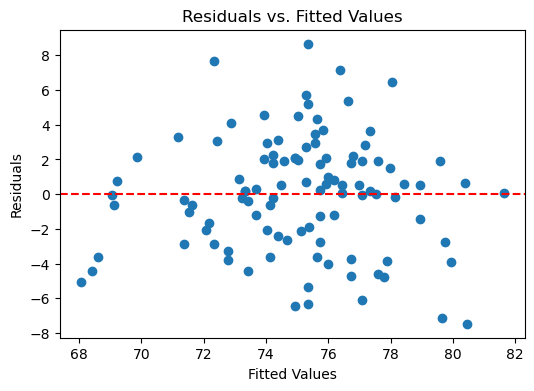

In [50]:
# Residuals vs. Fitted values plot = To check for independent observations and homoscedasticity,
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(fitted_values, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()


#The scatter plot of residuals vs. fitted values should have no distinct pattern if the assumption of linearity is met. 
#The generated plot did not show any obvious non-linear patterns.

## Question 4: Can we predict the total length of a Koala based on multiple factors such as head length, skull width, and foot length?

In [51]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define the independent variables (features) and the dependent variable (target)
X = df[['head_length','skull_width','foot_length']]
y = df['total_length']

# Add a constant term to the model (for the intercept)
X = sm.add_constant(X)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns

#X.shape[1] tells us how many features (or columns) we have in our dataset X. If we have, say, 5 features, X.shape[1] would be 5.
#range(X.shape[1]): This creates a sequence of numbers from 0 to the number of features minus one (so in our example, from 0 to 4). Each number corresponds to a different feature.
#variance_inflation_factor(X.values, i): For each feature (represented by i), this function calculates the VIF. 
#The function takes in all the data from X (as a NumPy array using X.values) and the specific feature index i to calculate the VIF.
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display the VIF data
print(vif_data)


'''NOTE: Calculating Variance Inflation Factor (VIF) for categorical independent variables in multiple regression analysis is not standard practice, and it generally doesn't make much sense.'''

       Feature        VIF
0        const  43.642489
1  head_length   1.798147
2  skull_width   1.739544
3  foot_length   1.148850


"NOTE: Calculating Variance Inflation Factor (VIF) for categorical independent variables in multiple regression analysis is not standard practice, and it generally doesn't make much sense."

In [52]:
# Define the independent variables (features) and the dependent variable (target)
X = df[['head_length','skull_width','foot_length']]
y = df['total_length']

# Add a constant term to the model (for the intercept)
#sm.add_constant(X) adds a column of ones to the matrix X.
#The added column represents the constant term (also known as the intercept)
X = sm.add_constant(X)

# Fit the multiple regression model
model = sm.OLS(y, X).fit()

# Display the summary of the regression model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           total_length   R-squared:                       0.511
Model:                            OLS   Adj. R-squared:                  0.497
Method:                 Least Squares   F-statistic:                     34.88
Date:                Mon, 14 Oct 2024   Prob (F-statistic):           1.64e-15
Time:                        22:44:19   Log-Likelihood:                -261.78
No. Observations:                 104   AIC:                             531.6
Df Residuals:                     100   BIC:                             542.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          55.0728      1.981     27.800      

In [53]:
# Check assumption

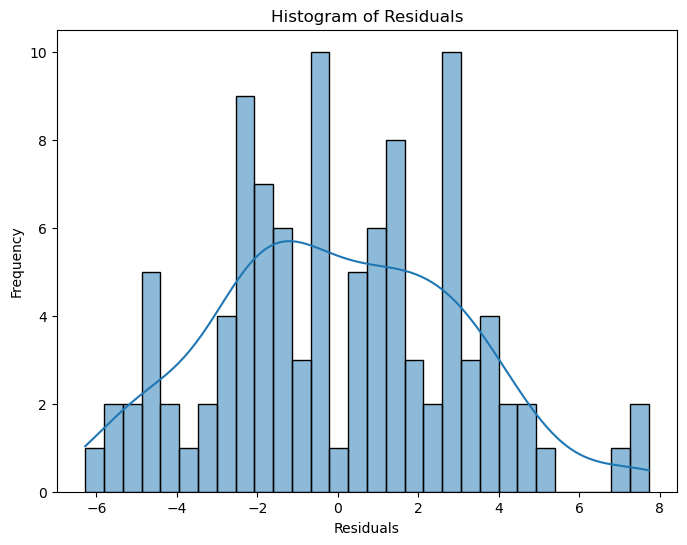

In [54]:
# Normality of Residuals

# Get the residuals
residuals = model.resid

# Histogram of residuals
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

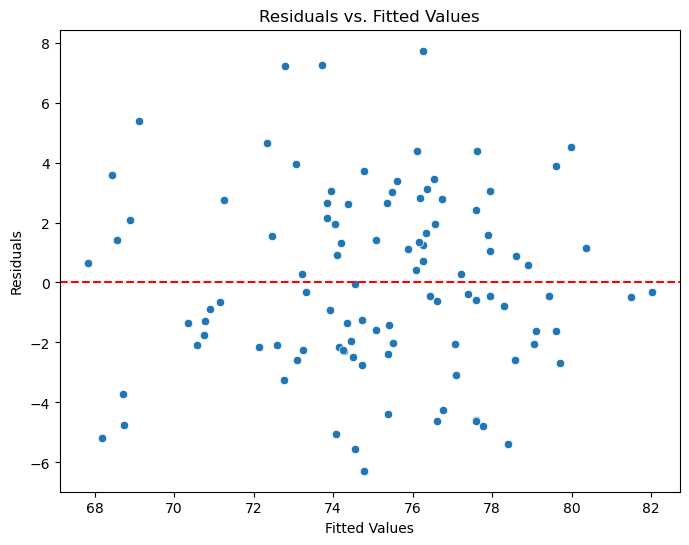

In [55]:
# Get fitted values
fitted_vals = model.fittedvalues

# Scatter plot of residuals vs. fitted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

## Question 5: Do environmental factors such as state affect Koala’s physical characteristics?

In [56]:
# One-hot encoding the "Color" column
one_hot_encoded_df = pd.get_dummies(df['habitat'], prefix='habitat', drop_first=True)

# Convert any boolean columns to integers (if necessary: incase you get False True values instead of zero/one)
one_hot_encoded_df = one_hot_encoded_df.astype(int)

# Concatenate the original DataFrame with the one-hot encoded columns
result_df = pd.concat([df, one_hot_encoded_df], axis=1)

In [57]:
# Define X (independent variables) as the one-hot encoded habitat and Y (dependent variables) as the koala physical characteristics
X = result_df[['habitat_VIC']]  # One-hot encoded habitat column
Y = result_df[['total_length', 'paw_size', 'head_length', 'ear_size', 
                'foot_length', 'skull_width', 'eye_diameter', 
                'chest_circumference', 'belly_circumference']]

# Add a constant to the independent variables (X) to account for the intercept
X = sm.add_constant(X)

# Create an OLS model for each physical characteristic
results = {}
for col in Y.columns:
    model = sm.OLS(Y[col], X).fit()
    results[col] = model.summary()

# Display the summaries for each model
for key in results:
    print(f"Summary for {key}:")
    print(results[key])

Summary for total_length:
                            OLS Regression Results                            
Dep. Variable:           total_length   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.6351
Date:                Mon, 14 Oct 2024   Prob (F-statistic):              0.427
Time:                        22:44:20   Log-Likelihood:                -298.70
No. Observations:                 104   AIC:                             601.4
Df Residuals:                     102   BIC:                             606.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          74.7879  

## Question 6: What factors are correlated with the total length of a Koala?

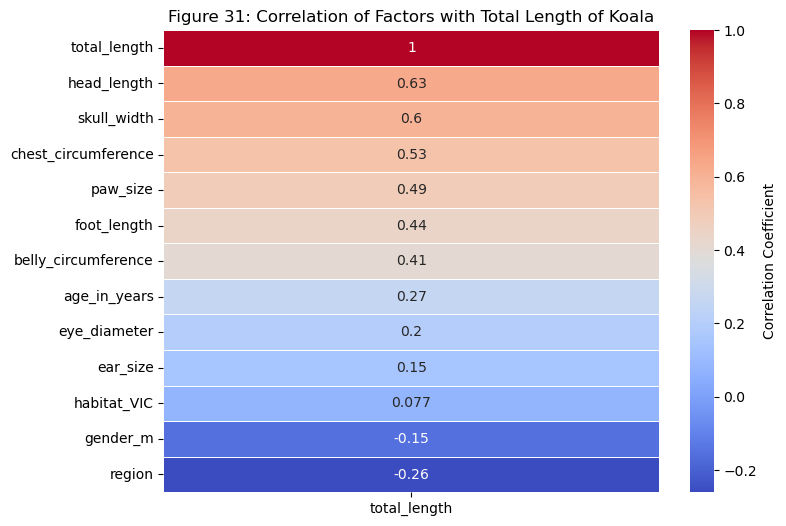

In [58]:
# One-hot encoding 'gender' and 'habitat' columns while dropping 'koala_id'
df_encoded = pd.get_dummies(df.drop('koala_id', axis=1), columns=['gender', 'habitat'], prefix=['gender', 'habitat'], drop_first=True)

# Convert boolean columns to integers if any exist (optional)
df_encoded = df_encoded.astype(int)

# Calculate the correlation matrix
correlation_matrix = df_encoded.corr()

# Extract correlations only for 'total_length'
correlation_with_total_length = correlation_matrix[['total_length']].sort_values(by='total_length', ascending=False)

# Plot heatmap for total length correlation
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_with_total_length, annot=True, cmap='coolwarm', cbar_kws={'label': 'Correlation Coefficient'}, linewidths=0.5)
plt.title('Figure 31: Correlation of Factors with Total Length of Koala')
plt.show()
